# Diffusion Policy on Push-T (ManiSkill)

**Runner notebook** — all logic lives in the project directory.

| Cell | What it does | Run again? |
|------|-------------|------------|
| 0 – Mount & paths | Add project to `sys.path` | Every restart |
| 1 – Install deps | Vulkan + pip (cached) | Every restart (~10 s after first run) |
| 2 – Sanity check | Quick env smoke-test | Optional |
| 3 – Download demos | Pull Push-T expert demos | Once ever |
| 4 – Convert demos | Convert to rgb + pd_ee_delta_pos format | Once ever |
| 5 – Configure | Build Config object; edit then re-run | Each experiment |
| 6 – Train | Full training loop; checkpoints saved | Per run |
| 7 – TensorBoard | Live loss/reward curves | Optional |
| 8 – Evaluate | Roll out best checkpoint | After training |
| 9 – Watch video | Display evaluation video | After eval |
| 10 – PPO baseline | State-based PPO for comparison | Optional |

## Cell 0 — Register project path
Run this **every** session restart.

In [1]:
import sys, os

# ── edit this path if you placed the project elsewhere ──
PROJECT_DIR = '/storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL'
# ────────────────────────────────────────────────────────────────

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

print(f'Project root: {PROJECT_DIR}')

Project root: /storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL


## Cell 1 — Install dependencies
Packages are cached so **subsequent restarts take ~10 seconds** instead of 3+ minutes.

In [2]:
from setup import full_setup

full_setup()  # Vulkan + pip install (cached)

[setup] Not on Colab — skipping Vulkan setup.
[setup] Running locally in: system Python (no active venv detected)
[setup] Skipping auto-install — manage packages in your own environment.

[setup] Install cross-platform packages (safe on macOS/Windows):
    pip install torch torchvision tyro diffusers einops zarr

[setup] Linux/GPU-only packages (install only on Colab / Linux + NVIDIA):
    # pip install gym-pusht
    # pip install mani_skill

[setup] Tip: mani_skill and gym-pusht both require an NVIDIA GPU and
[setup]      Linux. On macOS you can edit code but must run the sim on Colab.
[setup] Packages ready.
[setup] Environment ready.


## Cell 2 — Sanity check: run one episode of Push-T

In [3]:
import torch
import matplotlib
matplotlib.use("Agg")  # headless — no display needed
import matplotlib.pyplot as plt

from envs import make_pusht_env

print('Creating Push-T env with 4 parallel envs...')
env = make_pusht_env(num_envs=4, obs_mode='rgb')
obs, _ = env.reset(seed=0)
env.unwrapped.print_sim_details()

for _ in range(10):
    action = torch.from_numpy(env.action_space.sample())
    obs, rew, term, trunc, info = env.step(action)

# Pass the RGB tensor from obs directly — avoids all wrapper/render_mode issues
rgbs = obs['sensor_data']['base_camera']['rgb']  # (B, H, W, C) uint8
n = min(4, 4)
fig, axs = plt.subplots(1, n, figsize=(4 * n, 4))
for i, ax in enumerate(axs if n > 1 else [axs]):
    ax.imshow(rgbs[i].cpu().numpy())
    ax.axis('off')
plt.suptitle('Push-T sanity check')
plt.savefig(os.path.join(PROJECT_DIR, 'sanity_check.png'), bbox_inches='tight')
plt.show()
env.close()
print('Sanity check passed ✓')

/storage/home/hcoda1/1/ttyagi9/scratch/conda_envs/CRL/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/storage/home/hcoda1/1/ttyagi9/scratch/conda_envs/CRL/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/storage/home/hcoda1/1/ttyagi9/scratch/conda_envs/CRL/lib/python3.11/site-packages/sapien/_vulkan_tricks.py:78: UserWarning: Failed to find Vulkan ICD file. This is probably due to an incorrect or partial installation of the NVIDIA driver. SAPIEN will attempt to provide an ICD file anyway but it may not work.
  warn(


Creating Push-T env with 4 parallel envs...
# -------------------------------------------------------------------------- #
Task ID: PushT-v1, 4 parallel environments, sim_backend=physx_cuda
obs_mode=rgb, control_mode=pd_ee_delta_pos
render_mode=rgb_array, sensor_details=RGBD(128x128)
sim_freq=100, control_freq=20
observation space: Dict('agent': Dict('qpos': Box(-inf, inf, (4, 7), float32), 'qvel': Box(-inf, inf, (4, 7), float32)), 'extra': Dict('tcp_pose': Box(-inf, inf, (4, 7), float32)), 'sensor_data': Dict('base_camera': Dict('rgb': Box(0, 255, (4, 128, 128, 3), uint8))), 'sensor_param': Dict('base_camera': Dict('cam2world_gl': Box(-inf, inf, (4, 4, 4), float32), 'extrinsic_cv': Box(-inf, inf, (4, 3, 4), float32), 'intrinsic_cv': Box(-inf, inf, (4, 3, 3), float32))))
(single) action space: Box(-1.0, 1.0, (3,), float32)
# -------------------------------------------------------------------------- #
Sanity check passed ✓


## Cell 3 — Download Push-T demos
Skipped automatically if the file already exists.

In [4]:
from data import download_demos

demo_dir = download_demos(
    env_id='PushT-v1',
    output_dir=os.path.join(PROJECT_DIR, 'demos'),
)
print('Demo directory:', demo_dir)

[data] Demos already present at /storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL/demos/PushT-v1. Skipping download.
Demo directory: /storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL/demos/PushT-v1


## Cell 4 — Convert demos to RGB + pd_ee_delta_pos format
One-time step. Skipped on subsequent runs if the converted file exists.

In [5]:
from data.demo_loader import convert_demos

raw_traj = os.path.join(
    PROJECT_DIR, 'demos', 'PushT-v1', 'rl',
    'trajectory.none.pd_ee_delta_pos.physx_cuda.h5'
)
converted_traj = raw_traj.replace('trajectory.none.', 'trajectory.rgb.')

if not os.path.exists(converted_traj):
    converted_traj = convert_demos(
        traj_path=raw_traj,
        obs_mode='rgb',
        control_mode='pd_ee_delta_pos',
    )
else:
    print(f'Converted demos already exist: {converted_traj}')

print('Using:', converted_traj)

Converted demos already exist: /storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL/demos/PushT-v1/rl/trajectory.rgb.pd_ee_delta_pos.physx_cuda.h5
Using: /storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL/demos/PushT-v1/rl/trajectory.rgb.pd_ee_delta_pos.physx_cuda.h5


## Cell 5 — Configure the experiment
Edit values here, then re-run. Saved to config.json so you can reload any past config.

In [ ]:
from training.config import Config, EnvConfig, PolicyConfig, TrainConfig

# ManiSkill naming convention: trajectory.{obs_mode}.{control_mode}.physx_cuda.h5
converted_traj = os.path.join(
    PROJECT_DIR, 'demos', 'PushT-v1', 'rl',
    'trajectory.rgb.pd_ee_delta_pos.physx_cuda.h5'
)

cfg = Config(
    env=EnvConfig(
        env_id='PushT-v1',
        num_envs=64,
        eval_num_envs=10,
        obs_mode='rgb',
        image_size=96,
    ),
    policy=PolicyConfig(
        obs_horizon=2,
        pred_horizon=16,
        action_horizon=8,
        obs_cond_dim=256,
        num_diffusion_steps=100,
    ),
    train=TrainConfig(
        demo_path=converted_traj,
        normalizer_path=os.path.join(PROJECT_DIR, 'normalizer_stats.npz'),
        num_epochs=500,
        batch_size=256,
        lr=1e-4,
        ckpt_dir=os.path.join(PROJECT_DIR, 'checkpoints'),
        save_every=10,
        # resume_from=os.path.join(PROJECT_DIR, 'checkpoints/epoch_0050.pt'),  # uncomment to resume
        eval_every=10,
        eval_video_dir=os.path.join(PROJECT_DIR, 'eval_videos'),
        log_dir=os.path.join(PROJECT_DIR, 'runs'),
    ),
)

cfg.save(os.path.join(PROJECT_DIR, 'config.json'))

# Print unique output directories (run_id auto-generated in TrainConfig.__post_init__)
print(cfg)
print("\n=== Unique Output Directories ===")
print(f"Run ID: {cfg.train.run_id}")
print(f"Checkpoints: {cfg.train.ckpt_dir}")
print(f"Eval videos: {cfg.train.eval_video_dir}")
print(f"TensorBoard logs: {cfg.train.log_dir}")

[config] Saved to /storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL/config.json
{
  "env": {
    "env_id": "PushT-v1",
    "num_envs": 64,
    "eval_num_envs": 10,
    "obs_mode": "rgb",
    "control_mode": "pd_ee_delta_pos",
    "reward_mode": "dense",
    "image_size": 96
  },
  "policy": {
    "obs_horizon": 2,
    "pred_horizon": 16,
    "action_horizon": 8,
    "obs_cond_dim": 256,
    "num_diffusion_steps": 100
  },
  "train": {
    "demo_path": "/storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL/demos/PushT-v1/rl/trajectory.rgb.pd_ee_delta_pos.physx_cuda.h5",
    "normalizer_path": "/storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL/normalizer_stats.npz",
    "num_epochs": 3000,
    "batch_size": 256,
    "lr": 0.0001,
    "weight_decay": 1e-06,
    "lr_warmup_steps": 500,
    "ckpt_dir": "/storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL/checkpoints",
    "save_every": 10,
    "resume_from": null,
    "eval_every": 10,
    "eval_episodes": 10,


## Cell 6 — Train Diffusion Policy
Checkpoints are saved every `save_every` epochs.
If the runtime dies, set `resume_from` in Cell 5 and re-run from there.

In [ ]:
from training.trainer import Trainer

trainer = Trainer(cfg)
trainer.train()

## Cell 7 — TensorBoard (live during training)
Open a separate tab and run this cell while training is running in Cell 6.

In [20]:
%load_ext tensorboard
%tensorboard --logdir cfg.train.log_dir
# Or view all runs (includes subdirectories per run_id):
# %tensorboard --logdir /storage/home/hcoda1/1/ttyagi9/scratch/Github/Continual-RL/runs


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 1120171), started 0:46:39 ago. (Use '!kill 1120171' to kill it.)

Or plot the curve inline after training:

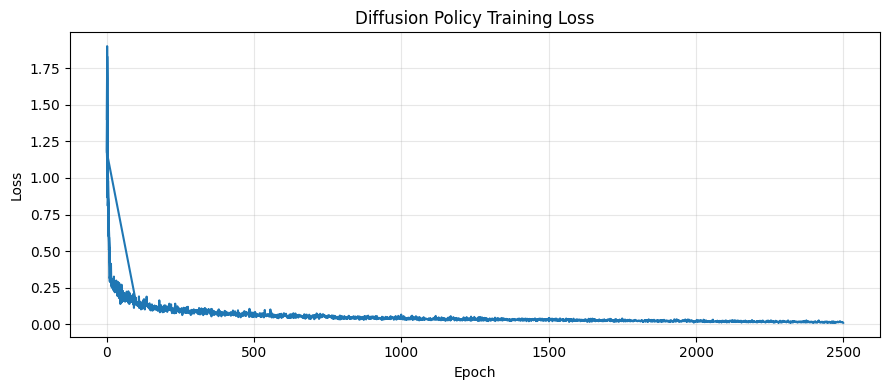

In [1]:
from utils.visualization import plot_training_curve

# Use cfg from cell 5 for dynamic path
plot_training_curve(cfg.train.log_dir)

## Cell 7c — Plot all training & eval metrics

Plots a 2x2 grid of all TensorBoard scalars: train/loss, train/lr, eval/mean_reward, eval/success_rate.

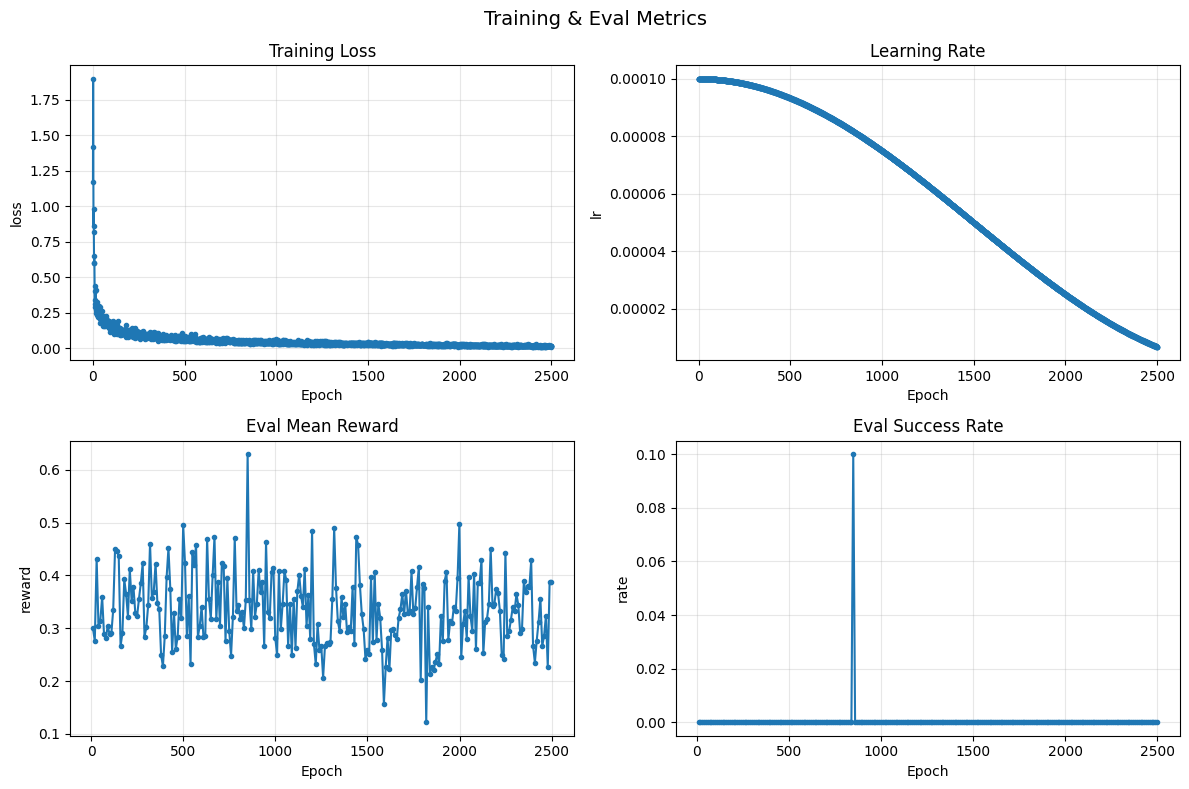

In [2]:
from utils.visualization import plot_tensorboard_metrics

plot_tensorboard_metrics(cfg.train.log_dir)

## Cell 8 — Evaluate a saved checkpoint

In [ ]:
import glob
from training.trainer import Trainer
from training.config import Config

# Load config from disk (in case kernel was restarted after training)
cfg = Config.load(os.path.join(PROJECT_DIR, 'config.json'))

# Pick the latest checkpoint automatically
ckpts = sorted(glob.glob(os.path.join(cfg.train.ckpt_dir, 'epoch_*.pt')))
if not ckpts:
    raise FileNotFoundError('No checkpoints found. Run Cell 6 first.')

cfg.train.resume_from = ckpts[-1]
print('Evaluating checkpoint:', cfg.train.resume_from)

trainer = Trainer(cfg)
epoch = int(os.path.basename(ckpts[-1]).split('epoch_')[1].split('.')[0])
metrics = trainer.evaluate(epoch=epoch)
print('Metrics:', metrics)

## Cell 9 — Watch an evaluation video

In [ ]:
import glob
from utils.visualization import display_video

# Find the most recent eval video
videos = sorted(glob.glob(os.path.join(cfg.train.eval_video_dir, '**/*.mp4'), recursive=True))
if not videos:
    print('No eval videos yet. Run Cell 8 first.')
else:
    print('Showing:', videos[-1])
    display_video(videos[-1], width=640)

## Cell 10 — (Optional) State-based PPO baseline
Downloads ManiSkill's PPO script and runs it. Useful to compare against Diffusion Policy.
PPO files are cached so they're not re-downloaded on restart.

In [ ]:
import os

PPO_DIR = os.path.join(PROJECT_DIR, 'baselines')
os.makedirs(PPO_DIR, exist_ok=True)

for script in ['ppo.py', 'ppo_rgb.py']:
    dst = os.path.join(PPO_DIR, script)
    if not os.path.exists(dst):
        url = f'https://raw.githubusercontent.com/haosulab/ManiSkill/main/examples/baselines/ppo/{script}'
        os.system(f'wget -q {url} -O {dst}')
        print(f'Downloaded {script}')
    else:
        print(f'{script} already cached.')

In [ ]:
# State-based PPO — edit flags as needed
!python {PPO_DIR}/ppo.py \
    --env_id='PushT-v1' \
    --exp-name='state-pusht' \
    --num_envs=1024 \
    --update_epochs=8 \
    --num_minibatches=32 \
    --total_timesteps=600_000 \
    --eval_freq=8 \
    --num-steps=20

In [ ]:
import glob
from utils.visualization import display_video

ppo_videos = sorted(glob.glob('runs/state-pusht/videos/*.mp4'))
if ppo_videos:
    display_video(ppo_videos[-1], width=1024)

## Extra — Replay an expert demo

In [ ]:
from data import load_demo_metadata, replay_episode
from utils.visualization import display_video

traj_path = os.path.join(
    PROJECT_DIR, 'demos', 'PushT-v1', 'rl',
    'trajectory.none.pd_ee_delta_pos.physx_cuda.h5'
)
h5, meta = load_demo_metadata(traj_path)
print(f'{len(meta["episodes"])} demos available.')

video_path = replay_episode(
    episode_idx=0,
    h5_file=h5,
    json_data=meta,
    save_dir=os.path.join(PROJECT_DIR, 'replays'),
)
display_video(video_path)